In [1]:
import matplotlib.pyplot as plt
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.utils.data import DataLoader

from torchvision.datasets import MNIST
from torchvision.transforms import transforms

from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [2]:
_ = torch.manual_seed(42)

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

In [4]:
train_dataset = MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = MNIST(root='./data', train=False, download=True, transform=transform)

len(train_dataset)
len(test_dataset)

img, label = train_dataset[0]
img.shape
label

60000

10000

torch.Size([1, 28, 28])

5

In [5]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,
                          num_workers=0, pin_memory=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False,
                         num_workers=0, pin_memory=False)

len(train_loader)
len(test_loader)

images, labels = next(iter(train_loader))
images.shape
labels.shape

# to verify reproducibility
labels[:10]

1875

313

torch.Size([32, 1, 28, 28])

torch.Size([32])

tensor([1, 2, 8, 5, 2, 6, 9, 9, 9, 4])

In [6]:
class MLP(nn.Module):
  def __init__(self):
    super(MLP, self).__init__()

    self.fc1 = nn.Linear(784, 128)
    self.fc2 = nn.Linear(128, 64)
    self.fc3 = nn.Linear(64, 10)
    self.dropout = nn.Dropout(0.20)

  def forward(self, x):
    # flatten the images: [batch, 1, 28, 28] -> [batch, 784]
    x = x.view(x.size(0), -1)

    # layer 1
    x = F.relu(self.fc1(x))
    x = self.dropout(x)

    # layer 2
    x = F.relu(self.fc2(x))
    x = self.dropout(x)

    # layer 3
    return self.fc3(x)

In [7]:
model = nn.Sequential(
    nn.Flatten(),

    # layer 1
    nn.Linear(784, 128),
    nn.ReLU(),
    nn.Dropout(0.20),

    # layer 2
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Dropout(0.20),

    # layer 3
    nn.Linear(64, 10),
)

total = 0
for name, param in model.named_parameters():
  total += param.numel()
  print(f'{name:<10} | {tuple(param.shape)}')

print(f'total params: {total}')

1.weight   | (128, 784)
1.bias     | (128,)
4.weight   | (64, 128)
4.bias     | (64,)
7.weight   | (10, 64)
7.bias     | (10,)
total params: 109386


In [8]:
# to verify reproducibility
next(iter(model.parameters())).flatten()[:10]

tensor([-0.0078,  0.0072, -0.0174,  0.0210,  0.0315, -0.0262,  0.0310,  0.0067,
         0.0264,  0.0048], grad_fn=<SliceBackward0>)

In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=0.0001)

In [10]:
history = {
    'train_loss': [], 'test_loss': [],
    'train_acc': [], 'test_acc': [],
}

NUM_EPOCHS = 5

for epoch in range(NUM_EPOCHS):
  print(f'THIS IS EPOCH {epoch}')

  train_loss_store = []
  train_acc_store = []
  test_loss_store = []
  test_acc_store = []

  # --- TRAINING PHASE ---
  _ = model.train()
  print('  TRAINING PHASE')
  for batch_idx, (images, labels) in enumerate(train_loader):
    # 1. clear the accumulated grads
    optimizer.zero_grad()

    # 2. ➡️FORWARD PASS to get outputs
    outputs = model(images)

    # 3. calc loss
    train_loss = criterion(outputs, labels)

    # 4. ⬅️BACKWARD PASS to calc grads
    train_loss.backward()

    # 5. update model params
    optimizer.step()

    # calc accuracy score
    labels_pred = torch.max(outputs, dim=1).indices
    train_acc = accuracy_score(labels, labels_pred)

    # store this batch's info
    train_loss_store.append(train_loss.item())
    train_acc_store.append(train_acc)

    if batch_idx % 200 == 0:
      print(f'  batch {batch_idx:>4}, loss {train_loss:.4f}, acc {train_acc:.2f}')

  # --- VALIDATION PHASE ---
  _ = model.eval()
  print('  VALIDATION PHASE')
  with torch.no_grad():
    for batch_idx, (images, labels) in enumerate(test_loader):
      outputs = model(images)
      test_loss = criterion(outputs, labels)
      labels_pred = torch.max(outputs, dim=1).indices
      test_acc = accuracy_score(labels, labels_pred)

      test_loss_store.append(test_loss.item())
      test_acc_store.append(test_acc)

      if batch_idx % 200 == 0:
        print(f'  batch {batch_idx:>4}, loss {test_loss:.4f}, acc {test_acc:.2f}')

  # capture history for this epoch
  history['train_loss'].append(np.mean(train_loss_store))
  history['train_acc'].append(np.mean(train_acc_store))
  history['test_loss'].append(np.mean(test_loss_store))
  history['test_acc'].append(np.mean(test_acc_store))

THIS IS EPOCH 0
  TRAINING PHASE
  batch    0, loss 2.3282, acc 0.03
  batch  200, loss 1.3156, acc 0.75
  batch  400, loss 0.7270, acc 0.78
  batch  600, loss 0.7399, acc 0.72
  batch  800, loss 0.4206, acc 0.84
  batch 1000, loss 0.6550, acc 0.75
  batch 1200, loss 0.6195, acc 0.84
  batch 1400, loss 0.5066, acc 0.88
  batch 1600, loss 0.3915, acc 0.94
  batch 1800, loss 0.4149, acc 0.88
  VALIDATION PHASE
  batch    0, loss 0.2484, acc 0.97
  batch  200, loss 0.3232, acc 0.84
THIS IS EPOCH 1
  TRAINING PHASE
  batch    0, loss 0.3005, acc 0.88
  batch  200, loss 0.4848, acc 0.81
  batch  400, loss 0.4499, acc 0.91
  batch  600, loss 0.5233, acc 0.84
  batch  800, loss 0.5842, acc 0.88
  batch 1000, loss 0.2105, acc 0.94
  batch 1200, loss 0.2986, acc 0.84
  batch 1400, loss 0.2877, acc 0.94
  batch 1600, loss 0.2972, acc 0.91
  batch 1800, loss 0.3080, acc 0.91
  VALIDATION PHASE
  batch    0, loss 0.2067, acc 0.97
  batch  200, loss 0.2366, acc 0.88
THIS IS EPOCH 2
  TRAINING PHASE

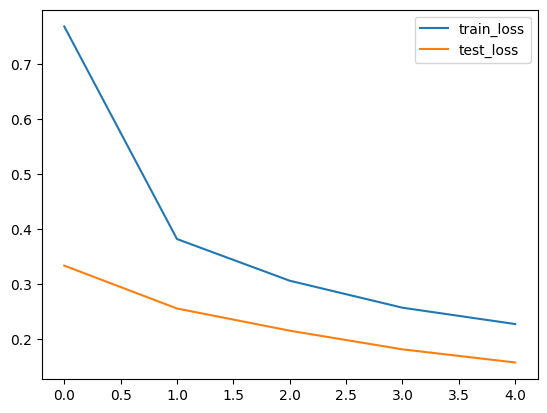

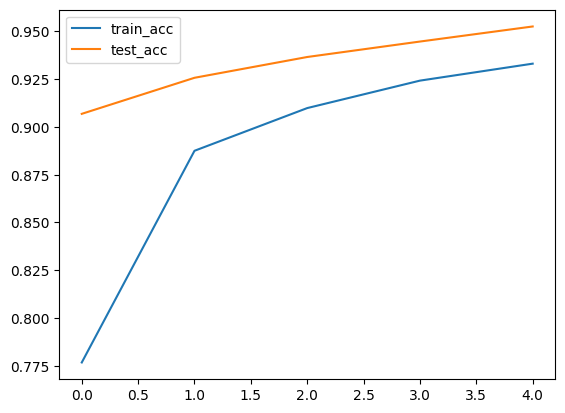

In [11]:
_ = plt.plot(history['train_loss'], label='train_loss')
_ = plt.plot(history['test_loss'], label='test_loss')
_ = plt.legend()
plt.show()

_ = plt.plot(history['train_acc'], label='train_acc')
_ = plt.plot(history['test_acc'], label='test_acc')
_ = plt.legend()

In [12]:
_ = model.eval()

all_labels = []
all_labels_pred = []

with torch.no_grad():
  for images, labels in test_loader:
    outputs = model(images)
    labels_pred = torch.max(outputs, dim=1).indices
    all_labels.extend(labels.tolist())
    all_labels_pred.extend(labels_pred.tolist())

print(len(all_labels), len(all_labels_pred))
print(all_labels[:10])
print(all_labels_pred[:10])

10000 10000
[7, 2, 1, 0, 4, 1, 4, 9, 5, 9]
[7, 2, 1, 0, 4, 1, 4, 9, 6, 9]


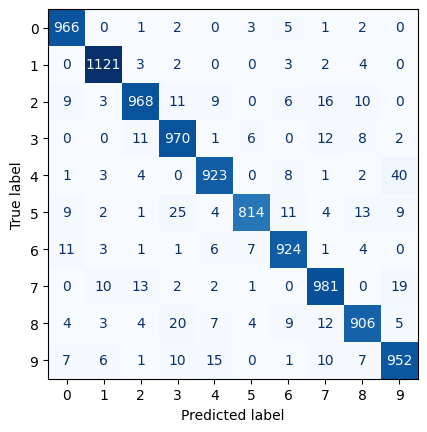

In [13]:
cm = confusion_matrix(all_labels, all_labels_pred)
cmd = ConfusionMatrixDisplay(cm)
_ = cmd.plot(cmap='Blues', colorbar=False)

In [14]:
torch.save(model.state_dict(), 'mnist-model.pth')

In [28]:
img, label = train_dataset[400]
label
img.unsqueeze(0).shape

2

torch.Size([1, 1, 28, 28])